# SpecGAN Training for Solar Radio Burst Generation

**Based on:** Chris Donahue's SpecGAN (https://github.com/chrisdonahue/wavegan)  
**Ported from:** TensorFlow to PyTorch  
**Data:** 128×128 CSV spectrogram windows of solar radio bursts

**Key SpecGAN Features:**
- Per-frequency bin normalization (preserves frequency-specific characteristics)
- WGAN-GP loss (more stable training than DCGAN)
- Single-channel architecture (matches grayscale spectrograms)
- 5×5 kernels (larger receptive field than DCGAN's 4×4)
- D:G update ratio of 5:1 (discriminator trains 5 times per generator update)

**Prerequisites:**
Run `compute_moments.py` BEFORE training to generate moments.npz file


## 1. Imports


In [1]:
import os
import sys
import random
import pandas
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from dotenv import load_dotenv

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.utils as vutils

# --- Import SpecGAN components ---
# Import Models
from specgan_models import SpecGANGenerator, SpecGANDiscriminator, weights_init

# Import Utils
from specgan_utils import (
    PerFrequencyNormalizer, GANLoss, compute_gradient_penalty,
    save_gan_checkpoint, load_gan_checkpoint, get_specgan_optimizer,
    SPECGAN_DEFAULTS
)

# Import Dataset
from spectrogram_dataset import SpectrogramDataset

# Load .env variables
load_dotenv()

# Load colored outputs
GREEN = '\033[32m'
RED = '\033[31m'
YELLOW = '\033[33m'
BLUE = '\033[34m'
RESET = '\033[0m'


## 2. Set Random Seed for Reproducibility


In [2]:
seed = int(os.getenv("SEED"))
print(f"Using Seed: {seed}")
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)


Using Seed: 999


## 3. Configuration (SpecGAN Defaults)

**From train_specgan.py, Lines 687-712**


In [3]:
# Data paths
data_root = os.getenv("DATA_ROOT")
moments_path = os.getenv("MOMENTS_PATH")
checkpoint_dir = os.getenv("CHECKPOINT_ROOT")

# SpecGAN architecture defaults (from Lines 697-700)
nz = 100              # Latent dimension (specgan_latent_dim)
nc = 1                # Number of channels (single-channel spectrogram)
kernel_len = 5        # Kernel size (specgan_kernel_len) - 5×5, not 4×4!
dim = 64              # Dimension multiplier (specgan_dim)
use_batchnorm = False # BatchNorm (specgan_batchnorm) - SpecGAN default is False

# Training parameters (from Lines 701-705)
disc_nupdates = int(os.getenv("DISC_NUPDATES"))     # D updates per G update (specgan_disc_nupdates) - Important!
loss_type = 'wgan-gp' # Loss function (specgan_loss) - WGAN-GP is SpecGAN default
batch_size = int(os.getenv("BATCH_SIZE"))      # Batch size (adjusted from 64 for small dataset)
num_epochs = int(os.getenv("EPOCHS"))      # Number of training epochs
workers = 2           # DataLoader workers

# Optimizer parameters for WGAN-GP (from Lines 261-269)
lr = 1e-4             # Learning rate (both G and D use same LR for WGAN-GP)
beta1 = 0.5           # Adam beta1
beta2 = 0.9           # Adam beta2

# GPU settings
ngpu = int(os.getenv("NPGU"))     # Number of GPUs

# Model saving
save_interval = int(os.getenv("SAVE_INTERVAL"))    # Save every N epochs

print("="*70)
print("SpecGAN Configuration (following original SpecGAN defaults)")
print("="*70)
print(f"Data root: {data_root}")
print(f"Moments file: {moments_path}")
print(f"Checkpoint dir: {checkpoint_dir}")
print(f"\nArchitecture (from specgan.py):")
print(f"\tLatent dim (nz): {nz}")
print(f"\tChannels (nc): {nc} (single-channel)")
print(f"\tKernel size: {kernel_len}×{kernel_len}")
print(f"\tDimension multiplier: {dim}")
print(f"\tBatchNorm: {use_batchnorm}")
print(f"\nTraining (from train_specgan.py):")
print(f"\tLoss type: {loss_type}")
print(f"\tD:G update ratio: {disc_nupdates}:1")
print(f"\tBatch size: {batch_size}")
print(f"\tEpochs: {num_epochs}")
print(f"\tLearning rate: {lr}")
print(f"\tAdam betas: ({beta1}, {beta2})")
print("-"*70)


SpecGAN Configuration (following original SpecGAN defaults)
Data root: ../input_data
Moments file: ../moments/moments.npz
Checkpoint dir: ../checkpoints

Architecture (from specgan.py):
	Latent dim (nz): 100
	Channels (nc): 1 (single-channel)
	Kernel size: 5×5
	Dimension multiplier: 64
	BatchNorm: False

Training (from train_specgan.py):
	Loss type: wgan-gp
	D:G update ratio: 5:1
	Batch size: 16
	Epochs: 5
	Learning rate: 0.0001
	Adam betas: (0.5, 0.9)
----------------------------------------------------------------------


## 4. Load Dataset with Per-Frequency Normalization

**Uses pre-computed moments from compute_moments.py**


*	Moments loaded from ../moments/moments.npz
 	Mean shape: (128,)
 	Std shape: (128,)
*	Loaded per-frequency moments from: ../moments/moments.npz
*	SpectrogramDataset initialized:
 	Root directory: ../input_data
 	Total files found: 160 (CSV: 0, NPY: 160)
 	Normalization method: per_frequency
 	Output channels: 1
 	Data augmentation: Enabled
 	Per-frequency normalizer: Ready
 	Location distribution (NPY):
 		USA: 36 files (22.5%)
 		MONGOLIA: 26 files (16.2%)
 		MEXART: 23 files (14.4%)
 		NORWAY: 17 files (10.6%)
 		ALASKA: 16 files (10.0%)
 		BIR: 16 files (10.0%)
 		INDIA: 13 files (8.1%)
 		AUSTRIA: 7 files (4.4%)
 		SSRT: 6 files (3.8%)

*	Using device: cpu

*	Loading sample batch...
 	Batch shape: torch.Size([16, 1, 128, 128])
 	Batch value range: [-0.136, 1.000]
 	Expected: [-1, 1] (per-frequency normalized)


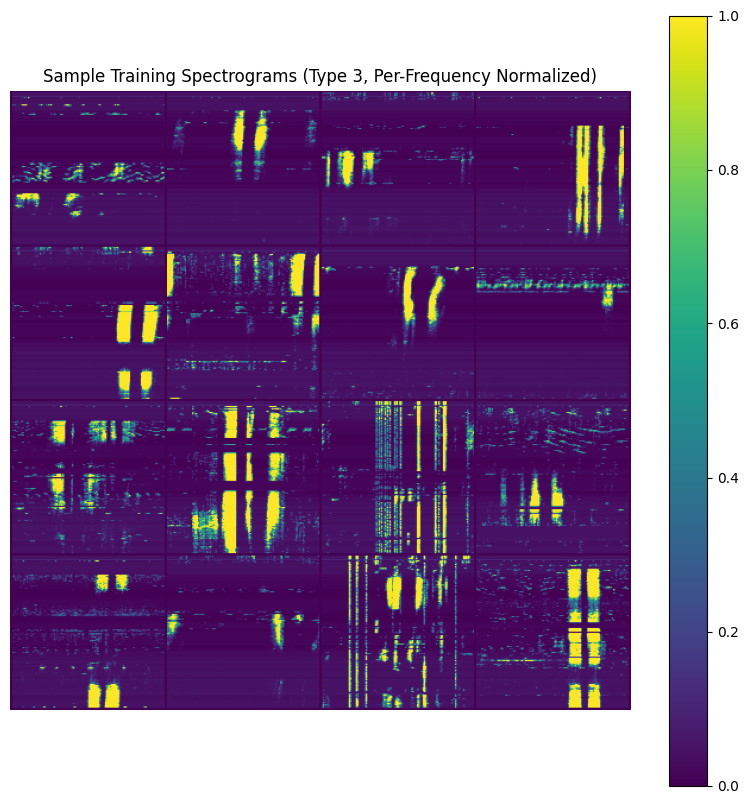

In [4]:
# Create dataset with SpecGAN features
# This replaces SpecGAN's loader.py + t_to_f() normalization
dataset = SpectrogramDataset(
    root_dir=data_root,
    normalize_method='per_frequency',  # SpecGAN's key feature!
    grayscale=True,                    # Single channel (nc=1)
    moments_path=moments_path,         # Load pre-computed moments
    augment=True,                      # Enable temporal shift augmentation
    subsample_ratio=1.0
)

# Create dataloader
dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=workers,
    drop_last=True  # Ensure consistent batch size
)

# Device configuration
device = torch.device("cuda:0" if (torch.cuda.is_available() and ngpu > 0) else "cpu")
print(f"\n*\tUsing device: {device}")

# Visualize sample batch
print("\n*\tLoading sample batch...")
real_batch = next(iter(dataloader))
print(f" \tBatch shape: {real_batch.shape}")  # Should be [batch_size, 1, 128, 128]
print(f" \tBatch value range: [{real_batch.min():.3f}, {real_batch.max():.3f}]")
print(f" \tExpected: [-1, 1] (per-frequency normalized)")

# Visualize
plt.figure(figsize=(10, 10))
plt.axis("off")
plt.title("Sample Training Spectrograms (Type 3, Per-Frequency Normalized)")
# For single channel, we need to convert [N,1,H,W] to displayable format
grid = vutils.make_grid(real_batch[:16].to(device), padding=2, normalize=True, nrow=4)
plt.imshow(grid.cpu().permute(1, 2, 0)[:,:,0], cmap='viridis')  # Show single channel
plt.colorbar()
plt.show()


## 5. Build Models (SpecGAN Architecture)

**From specgan.py: SpecGANGenerator and SpecGANDiscriminator**


In [5]:
# Create Generator
# From specgan.py, Lines 47-111
netG = SpecGANGenerator(
    nz=nz,
    kernel_len=kernel_len,
    dim=dim,
    nc=nc,
    use_batchnorm=use_batchnorm,
    ngpu=ngpu
).to(device)

# Create Discriminator  
# From specgan.py, Lines 122-178
netD = SpecGANDiscriminator(
    kernel_len=kernel_len,
    dim=dim,
    nc=nc,
    use_batchnorm=use_batchnorm,
    ngpu=ngpu
).to(device)

# Handle multi-GPU if available
if (device.type == 'cuda') and (ngpu > 1):
    netG = nn.DataParallel(netG, list(range(ngpu)))
    netD = nn.DataParallel(netD, list(range(ngpu)))

# Apply weight initialization (DCGAN standard)
netG.apply(weights_init)
netD.apply(weights_init)

# Print model summaries (from train_specgan.py, Lines 135-175)
print("\n" + "="*70)
print("Generator Architecture")
print("="*70)
print(netG)
total_params_g = sum(p.numel() for p in netG.parameters())
print(f"Total params: {total_params_g:,} ({total_params_g * 4 / (1024*1024):.2f} MB)")

print("\n" + "="*70)
print("Discriminator Architecture")
print("="*70)
print(netD)
total_params_d = sum(p.numel() for p in netD.parameters())
print(f"Total params: {total_params_d:,} ({total_params_d * 4 / (1024*1024):.2f} MB)")
print("-"*70)



Generator Architecture
SpecGANGenerator(
  (fc): Linear(in_features=100, out_features=16384, bias=True)
  (upconv0): ConvTranspose2d(1024, 512, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
  (upconv1): ConvTranspose2d(512, 256, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
  (upconv2): ConvTranspose2d(256, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
  (upconv3): ConvTranspose2d(128, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
  (upconv4): ConvTranspose2d(64, 1, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
  (relu): ReLU(inplace=True)
  (tanh): Tanh()
)
Total params: 19,065,345 (72.73 MB)

Discriminator Architecture
SpecGANDiscriminator(
  (conv0): Conv2d(1, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (conv1): Conv2d(64, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (conv2): Conv2d(128, 256, kernel_size=(5, 5

## 6. Setup Optimizers (SpecGAN Recommended Settings)

**From train_specgan.py, Lines 261-269 (WGAN-GP settings)**


In [6]:
# Get optimizers based on loss type
# Using helper function that implements Lines 243-271
optimizerG, optimizerD = get_specgan_optimizer(netG, netD, loss_type=loss_type)

# For WGAN-GP (default), both use:
# - learning_rate = 1e-4
# - beta1 = 0.5, beta2 = 0.9

print("*\tOptimizers initialized")
print(f" \tLoss type: {loss_type}")
print(f" \tLearning rate: {lr}")
print(f" \tAdam betas: ({beta1}, {beta2})")

# Fixed noise for visualization (similar to SpecGAN's preview)
fixed_noise = torch.randn(64, nz, device=device)


*	Optimizers initialized
 	Loss type: wgan-gp
 	Learning rate: 0.0001
 	Adam betas: (0.5, 0.9)


## 7. Training Loop (SpecGAN Training Strategy)

**From train_specgan.py, Lines 278-295:**
- Train Discriminator `disc_nupdates` times (default: 5)
- Then train Generator once
- Uses WGAN-GP loss with gradient penalty


In [7]:
# Training tracking lists
img_list = []
G_losses = []
D_losses = []
D_real_history = []
D_fake_history = []
iters = 0

# Best model tracking
# For WGAN-GP, we use -abs(D_fake) which is always negative
# So initialize to negative infinity to allow any improvement
best_quality_metric = -float('inf')  # Start from worst possible value
best_epoch = 0

print("="*70)
print("Starting SpecGAN Training Loop")
print("="*70)
print(f"Total batches per epoch: {len(dataloader)}")
print(f"Total iterations: {num_epochs * len(dataloader)}")
print(f"\nSpecGAN Training Strategy:")
print(f"\t- Loss: {loss_type}")
print(f"\t- D updates: {disc_nupdates} times per G update")
print(f"\t- Per-frequency normalization: Enabled")
print(f"\t- Temporal augmentation: Enabled")
print(f"\t- Single channel (nc={nc})")
print("-"*70)
print()

# Main training loop
for epoch in range(num_epochs):
    epoch_D_loss = []
    epoch_G_loss = []
    epoch_D_real = []
    epoch_D_fake = []
    
    for i, data in enumerate(dataloader, 0):
        real_data = data.to(device)
        b_size = real_data.size(0)
        
        ############################
        # (1) Update D network: Train discriminator multiple times
        #     From train_specgan.py, Lines 287-292
        ############################
        for d_iter in range(disc_nupdates):
            netD.zero_grad()
            
            # Forward pass real batch through D
            D_real = netD(real_data)
            
            # Generate fake batch
            noise = torch.randn(b_size, nz, device=device)
            fake_data = netG(noise)
            
            # Forward pass fake batch through D
            D_fake = netD(fake_data.detach())
            
            # Compute loss (WGAN-GP from Lines 222-236)
            if loss_type == 'wgan-gp':
                # Note: We only compute D_loss here; G_loss computed separately
                _, D_loss = GANLoss.wgan_gp_loss(
                    D_real, D_fake, netD, real_data, fake_data.detach(), device, lambda_gp=10
                )
            elif loss_type == 'dcgan':
                _, D_loss = GANLoss.dcgan_loss(D_real, D_fake)
            elif loss_type == 'lsgan':
                _, D_loss = GANLoss.lsgan_loss(D_real, D_fake)
            elif loss_type == 'wgan':
                _, D_loss = GANLoss.wgan_loss(D_real, D_fake)
            
            # Backprop and optimize D
            D_loss.backward()
            optimizerD.step()
            
            # Weight clipping for vanilla WGAN (not WGAN-GP)
            # From Lines 291-292
            if loss_type == 'wgan':
                from specgan_utils import clip_discriminator_weights
                clip_discriminator_weights(netD, clip_value=0.01)
        
        ############################
        # (2) Update G network: Train generator once
        #     From train_specgan.py, Lines 294-295
        ############################
        netG.zero_grad()
        
        # Generate new fake batch (don't reuse from D training)
        noise = torch.randn(b_size, nz, device=device)
        fake_data = netG(noise)
        
        # Forward through D
        D_fake_for_G = netD(fake_data)
        
        # Compute G loss
        if loss_type == 'wgan-gp' or loss_type == 'wgan':
            G_loss = -torch.mean(D_fake_for_G)  # Wasserstein
        elif loss_type == 'dcgan':
            G_loss, _ = GANLoss.dcgan_loss(D_real, D_fake_for_G)
        elif loss_type == 'lsgan':
            G_loss, _ = GANLoss.lsgan_loss(D_real, D_fake_for_G)
        
        # Backprop and optimize G
        G_loss.backward()
        optimizerG.step()
        
        # Record statistics
        D_real_mean = D_real.mean().item()
        D_fake_mean = D_fake_for_G.mean().item()
        
        epoch_D_loss.append(D_loss.item())
        epoch_G_loss.append(G_loss.item())
        epoch_D_real.append(D_real_mean)
        epoch_D_fake.append(D_fake_mean)
        
        # Save for plotting
        G_losses.append(G_loss.item())
        D_losses.append(D_loss.item())
        
        # Output training stats every 5 batches
        if i % 5 == 0:
            print(f'[{epoch}/{num_epochs}][{i}/{len(dataloader)}] '
                  f'Loss_D: {D_loss.item():.4f} Loss_G: {G_loss.item():.4f} '
                  f'D(real): {D_real_mean:.4f} D(fake): {D_fake_mean:.4f}')
        
        # Save generated images periodically
        if (iters % 100 == 0) or ((epoch == num_epochs-1) and (i == len(dataloader)-1)):
            with torch.no_grad():
                fake = netG(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake, padding=2, normalize=True, nrow=8))
        
        iters += 1
    
    # ===== End of epoch - evaluate and save models =====
    avg_D_loss = np.mean(epoch_D_loss)
    avg_G_loss = np.mean(epoch_G_loss)
    avg_D_real = np.mean(epoch_D_real)
    avg_D_fake = np.mean(epoch_D_fake)
    
    D_real_history.append(avg_D_real)
    D_fake_history.append(avg_D_fake)
    
    print(f"\n{'='*70}")
    print(f"Epoch {epoch} Summary:")
    print(f"\tAvg D_loss: {avg_D_loss:.4f}")
    print(f"\tAvg G_loss: {avg_G_loss:.4f}")
    print(f"\tAvg D(real): {avg_D_real:.4f}")
    print(f"\tAvg D(fake): {avg_D_fake:.4f}")
    print(f"\tBest quality so far: {best_quality_metric:.4f} (Epoch {best_epoch})")
    
    # Save model if quality improved
    # For WGAN-GP, D(fake) closer to 0 is ideal (around 0 means balanced)
    # We use abs(D(fake)) as quality metric - lower is better for WGAN
    quality_metric = avg_D_fake if loss_type in ['dcgan', 'lsgan'] else -abs(avg_D_fake)
    
    if quality_metric > best_quality_metric:
        improvement = quality_metric - best_quality_metric
        best_quality_metric = quality_metric
        best_epoch = epoch
        
        print(f"*\t{GREEN}Quality improved by {improvement:.4f}! Saving checkpoint...{RESET}")
        save_gan_checkpoint(
            netG, netD, optimizerG, optimizerD, epoch, quality_metric,
            checkpoint_dir,
            hyperparams={'nz': nz, 'nc': nc, 'kernel_len': kernel_len, 'dim': dim}
        )
    else:
        print(f"*\t{YELLOW}No improvement this epoch{RESET}")
    
    # Periodic save
    if (epoch + 1) % save_interval == 0:
        periodic_path = os.path.join(checkpoint_dir, f"periodic_epoch_{epoch}.pth")
        torch.save({
            'epoch': epoch,
            'generator_state_dict': netG.state_dict(),
            'discriminator_state_dict': netD.state_dict(),
            'optimizerG_state_dict': optimizerG.state_dict(),
            'optimizerD_state_dict': optimizerD.state_dict(),
        }, periodic_path)
        print(f"*\t{GREEN}Periodic save: {periodic_path}{RESET}")
    
    print("="*70 + "\n")

print(f"\n*\t{GREEN}Training completed!{RESET}")
print(f"Best quality metric: {best_quality_metric:.4f} (Epoch {best_epoch})")


Starting SpecGAN Training Loop
Total batches per epoch: 10
Total iterations: 50

SpecGAN Training Strategy:
	- Loss: wgan-gp
	- D updates: 5 times per G update
	- Per-frequency normalization: Enabled
	- Temporal augmentation: Enabled
	- Single channel (nc=1)
----------------------------------------------------------------------

[0/5][0/10] Loss_D: 8.1546 Loss_G: -0.0476 D(real): 0.4033 D(fake): 0.0476
[0/5][5/10] Loss_D: -14.1104 Loss_G: 32.4289 D(real): -14.9721 D(fake): -32.4289

Epoch 0 Summary:
	Avg D_loss: -19.3461
	Avg G_loss: 30.8141
	Avg D(real): -0.2110
	Avg D(fake): -30.8141
	Best quality so far: -inf (Epoch 0)
*	Quality improved by inf! Saving checkpoint...
*	Checkpoint saved: epoch 0, quality -30.8141
 	Path: ../checkpoints/checkpoint_epoch_0_quality_-30.8141.pth

[1/5][0/10] Loss_D: -30.2111 Loss_G: 34.1853 D(real): 5.8261 D(fake): -34.1853
[1/5][5/10] Loss_D: -54.6856 Loss_G: 37.5597 D(real): 37.8368 D(fake): -37.5597

Epoch 1 Summary:
	Avg D_loss: -38.4682
	Avg G_loss: 

## 8. Plot Loss Curves

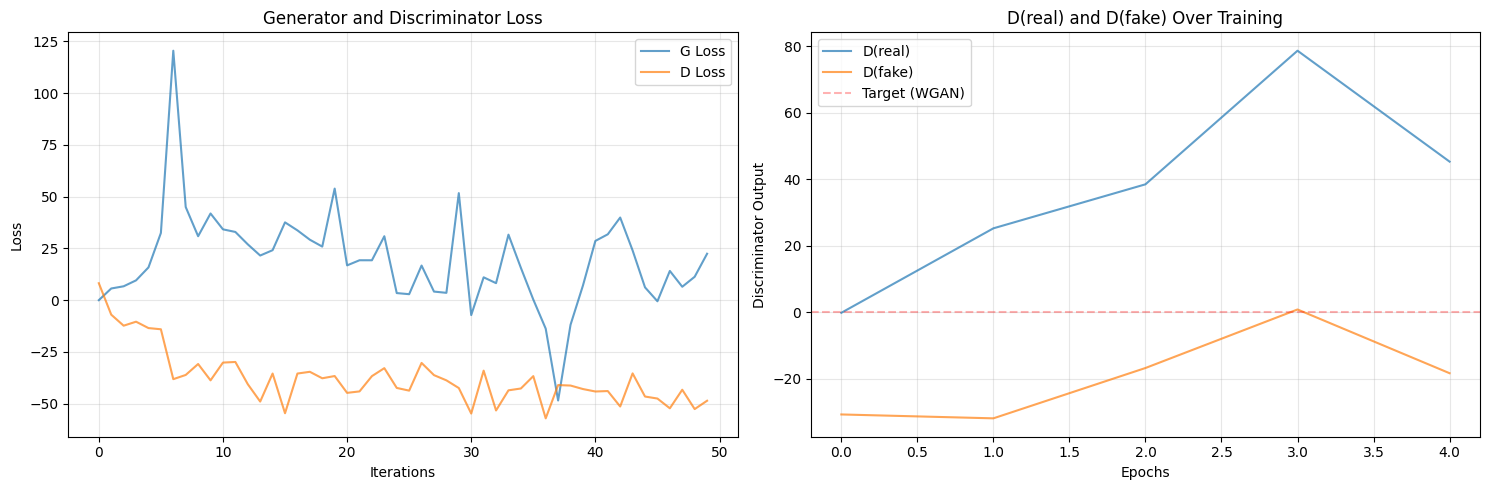

In [8]:
# Plot loss curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss curves
axes[0].plot(G_losses, label='G Loss', alpha=0.7)
axes[0].plot(D_losses, label='D Loss', alpha=0.7)
axes[0].set_xlabel('Iterations')
axes[0].set_ylabel('Loss')
axes[0].set_title('Generator and Discriminator Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# D(real) and D(fake) curves
axes[1].plot(D_real_history, label='D(real)', alpha=0.7)
axes[1].plot(D_fake_history, label='D(fake)', alpha=0.7)
axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.3, label='Target (WGAN)')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Discriminator Output')
axes[1].set_title('D(real) and D(fake) Over Training')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Visualize Training Progress (Animation)


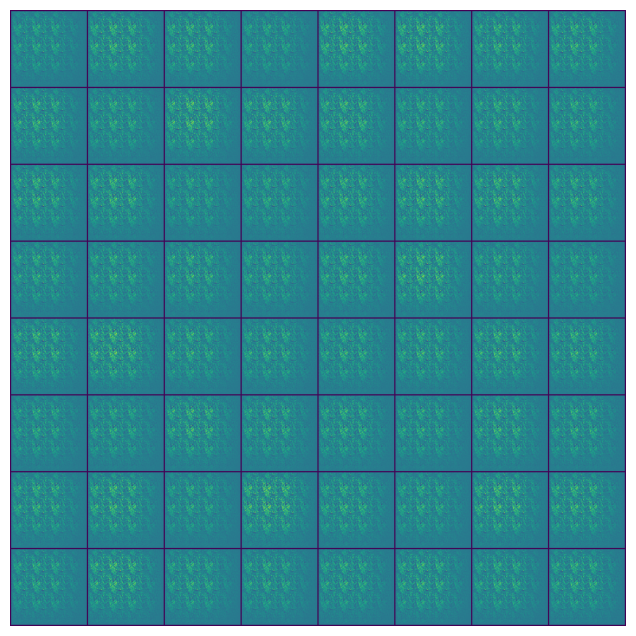

In [9]:
# Animation showing generator progress over time
fig = plt.figure(figsize=(8, 8))
plt.axis("off")

# For single-channel images, we need to handle them specially
ims = []
for img_grid in img_list:
    # img_grid is [C, H, W], take first channel for grayscale
    im = plt.imshow(img_grid[0].numpy(), animated=True, cmap='viridis')
    ims.append([im])

ani = animation.ArtistAnimation(fig, ims, interval=1000, repeat_delay=1000, blit=True)
HTML(ani.to_jshtml())


## 11. Final Generated Spectrograms


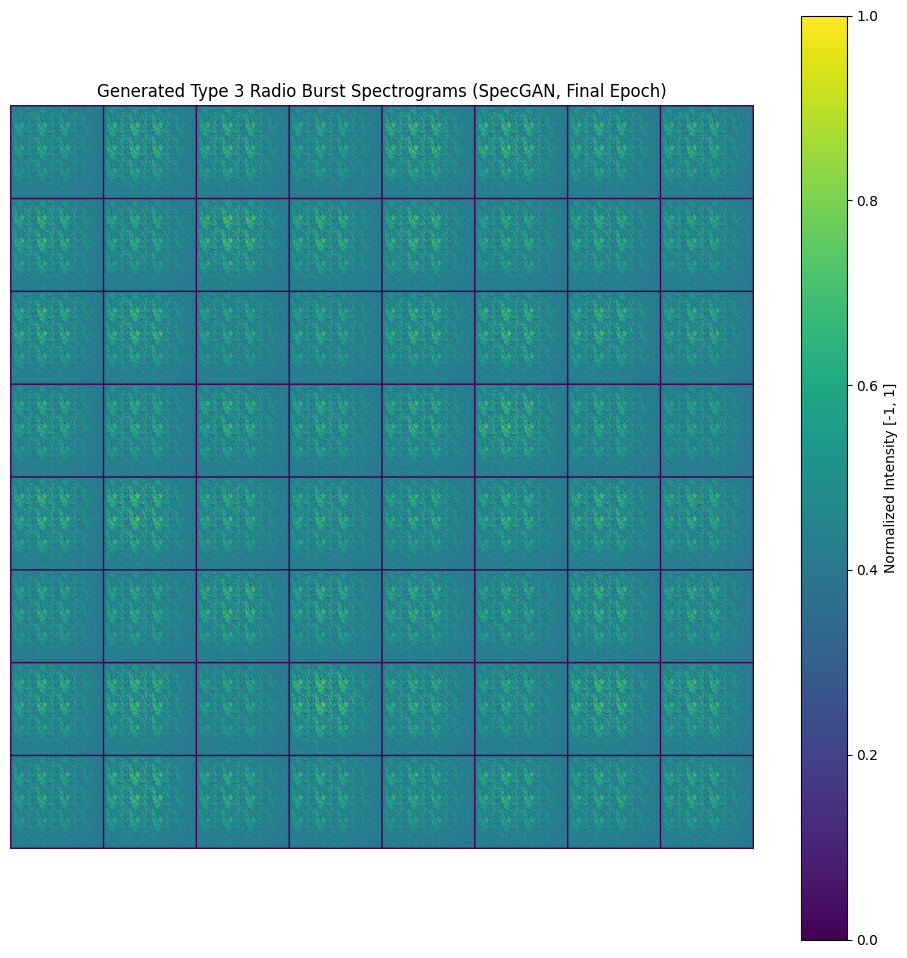

In [10]:
# Visualize final generated spectrograms
plt.figure(figsize=(12, 12))
plt.axis("off")
plt.title("Generated Type 3 Radio Burst Spectrograms (SpecGAN, Final Epoch)")
# Show single-channel image with hot colormap
plt.imshow(img_list[-1][0].numpy(), cmap='viridis')
plt.colorbar(label='Normalized Intensity [-1, 1]')
plt.show()


## 12. Real vs Fake Comparison


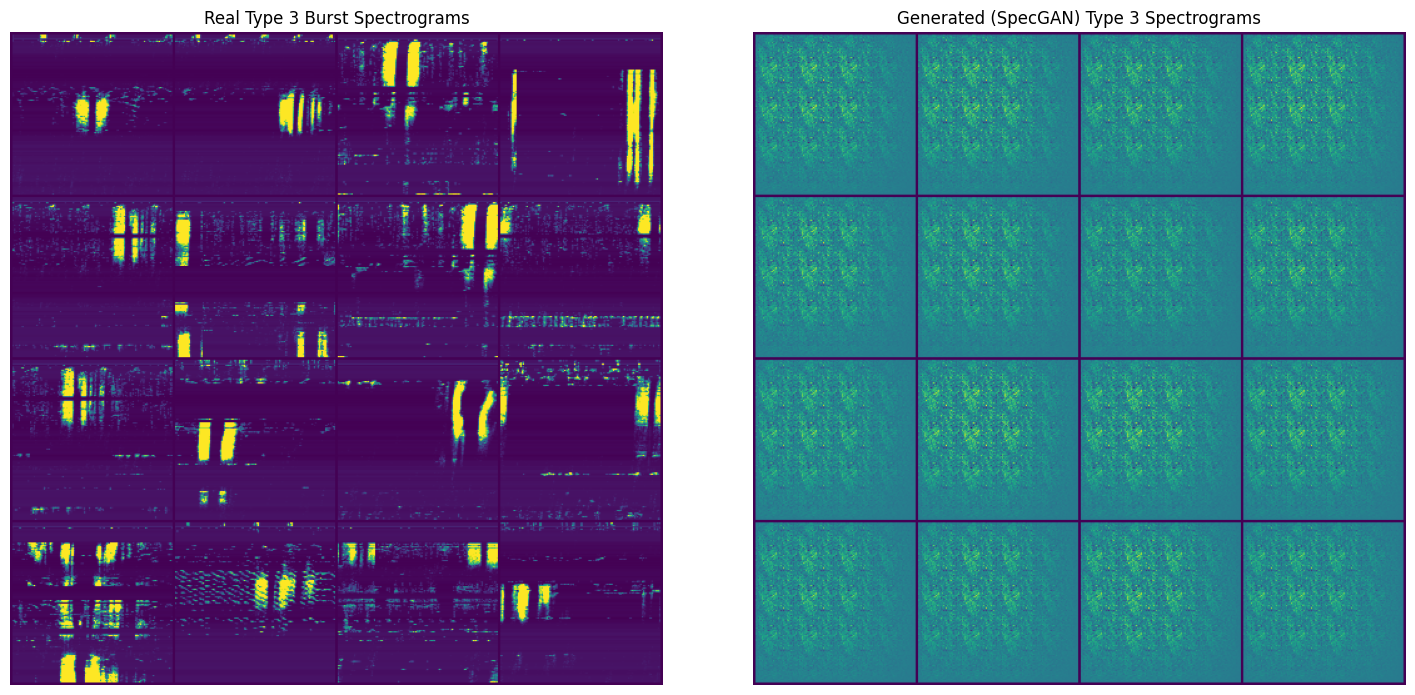

In [11]:
# Load a batch of real images
real_batch = next(iter(dataloader))

# Generate fake images
with torch.no_grad():
    noise = torch.randn(batch_size, nz, device=device)
    fake_batch = netG(noise).cpu()

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Real spectrograms
axes[0].imshow(vutils.make_grid(real_batch[:16], nrow=4, padding=2, normalize=True)[0].numpy(), cmap='viridis')
axes[0].set_title("Real Type 3 Burst Spectrograms")
axes[0].axis('off')

# Fake spectrograms  
axes[1].imshow(vutils.make_grid(fake_batch[:16], nrow=4, padding=2, normalize=True)[0].numpy(), cmap='viridis')
axes[1].set_title("Generated (SpecGAN) Type 3 Spectrograms")
axes[1].axis('off')

plt.tight_layout()
plt.show()


## 13. Generate New Samples from Best Model


*	Loading checkpoint...
*	Loading: periodic_epoch_4.pth
*	Checkpoint loaded: epoch 4, quality 0.0000
 	From: ../checkpoints/periodic_epoch_4.pth
*	Loaded model from Epoch 4


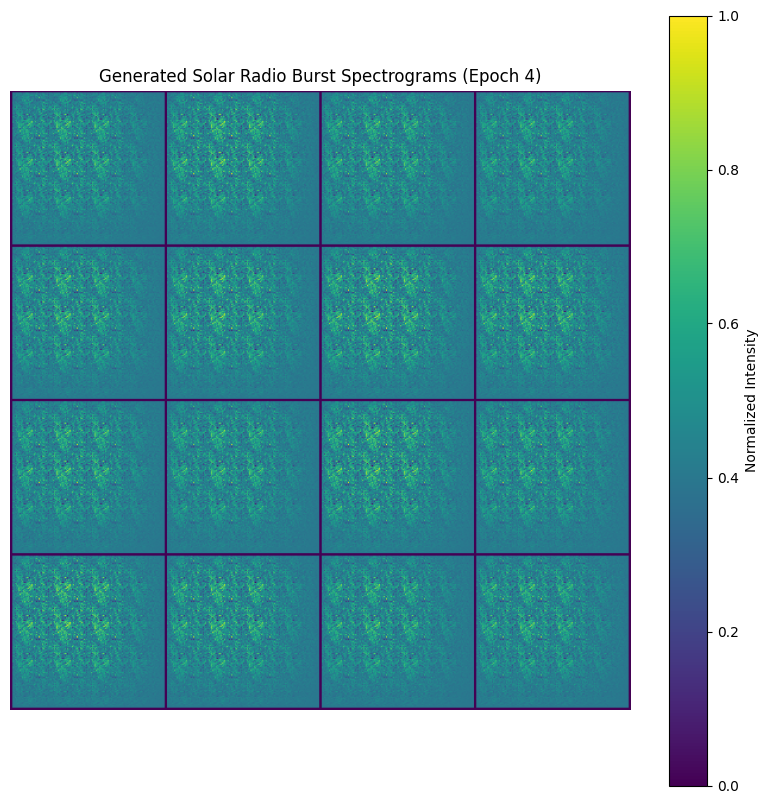

*	Generated 16 synthetic spectrograms from best checkpoint!


In [12]:
# ============================================================
# Load checkpoint and generate new samples
# ============================================================

# Configuration: Choose which epoch to load
load_mode = os.getenv("LOAD_MODE")  # Options: 'best', 'latest', or specific epoch number (e.g., 50)

print("*\tLoading checkpoint...")

from specgan_utils import find_best_checkpoint
from glob import glob

used_epoch = 0
try:
    if load_mode == 'best':
        # Load best quality checkpoint
        best_checkpoint_path = find_best_checkpoint(checkpoint_dir, metric='quality')
        checkpoint_path = best_checkpoint_path
        
    elif load_mode == 'latest':
        # Load most recent periodic checkpoint
        periodic_files = glob(os.path.join(checkpoint_dir, 'periodic_epoch_*.pth'))
        if periodic_files:
            # Sort by epoch number
            periodic_files.sort(key=lambda x: int(x.split('_')[-1].split('.')[0]))
            checkpoint_path = periodic_files[-1]
        else:
            raise FileNotFoundError("No periodic checkpoints found")
            
    elif isinstance(load_mode, int):
        # Load specific epoch
        checkpoint_path = os.path.join(checkpoint_dir, f'periodic_epoch_{load_mode}.pth')
        if not os.path.exists(checkpoint_path):
            raise FileNotFoundError(f"{RED}Checkpoint for epoch {load_mode} not found{RESET}")
    
    print(f"*\tLoading: {os.path.basename(checkpoint_path)}")
    
    # Load checkpoint
    checkpoint = load_gan_checkpoint(checkpoint_path, netG, netD, device=device)
    print(f"*\t{GREEN}Loaded model from Epoch {checkpoint['epoch']}{RESET}")
    if 'quality_metric' in checkpoint:
        print(f" \tQuality metric: {checkpoint['quality_metric']:.4f}")
        
    used_epoch = checkpoint['epoch']
    
except Exception as e:
    print(f"*\t{YELLOW}Could not load checkpoint: {e}{RESET}")
    print(" \tUsing current trained model instead...")

# Generate new samples
num_samples = int(os.getenv("NEW_SAMPLES"))

with torch.no_grad():
    noise = torch.randn(num_samples, nz, device=device)
    generated = netG(noise).cpu()

# Visualize
plt.figure(figsize=(10, 10))
plt.axis("off")
plt.title(f"Generated Solar Radio Burst Spectrograms (Epoch {used_epoch})")
grid = vutils.make_grid(generated, padding=2, normalize=True, nrow=4)
plt.imshow(grid[0].numpy(), cmap='viridis')  # Single channel
plt.colorbar(label='Normalized Intensity')
plt.show()

print(f"*\t{GREEN}Generated {num_samples} synthetic spectrograms from best checkpoint!{RESET}")


## 14. Save Generated Samples to Disc

In [13]:
# Get the output directory
output_dir = os.getenv("TRAINING_OUTPUT_ROOT")

# Check directory exists
if not os.path.exists(output_dir):
    print(f"*\t{RED}Output directory {output_dir} does not exist{RESET}")
    exit(1)

# Iterate through each sample
current_sample = 0
for sample in generated:
    np.save(os.path.join(output_dir, f'sample_{current_sample}.npy'), sample)
    current_sample += 1
    
print(f"\n*\t{GREEN}Saved {num_samples} synthetic spectrograms from best checkpoint!{RESET}")


*	Saved 16 synthetic spectrograms from best checkpoint!


## 14. SpecGAN vs DCGAN Comparison Summary

**Key Improvements from SpecGAN:**
1. **Per-frequency normalization** - Each frequency bin normalized independently
2. **Single-channel design** - Matches spectrogram data (no artificial RGB)
3. **5×5 kernels** - Larger receptive field than DCGAN's 4×4
4. **WGAN-GP loss** - More stable training than BCE
5. **5:1 D:G ratio** - Discriminator trains more to stay balanced
6. **Temporal augmentation** - Random shifts break spatial bias

**Expected improvements over original DCGAN:**
- Reduced horizontal striping (per-frequency norm handles frequency-dependent noise)
- Eliminated left-side concentration (temporal augmentation)
- Better stability (WGAN-GP loss)
- Cleaner frequency structures (domain-aware normalization)
